<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_full_fine_tune_tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **Note:** If you're running in Google Colab, make sure to enable GPU usage by going to Runtime -> Change runtime type -> select GPU.

[Source Code](https://github.com/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_full_fine_tune_tutorial.ipynb) | [Walkthrough video on YouTube](https://youtu.be/2hoNAr-id-E)


## Overview

In this project, we're going to fine-tune a base Small Language Model (SLM) to extract food and drink items from text.

Why?

This is often referred to as *structured data extraction**.

It's a very common problem throughout many businesses.

For example, say you were getting a large volume of emails in plain text and needed to extract customer details from them.

Or you wanted to analyze a large number of news reports for specific details.

Or in our case, say you were building an app like [Nutrify](https://nutrify.app) and you wanted to filter a large dataset of image captions for food/drink items (see the dataset [`mrdbourke/Recap-DataComp-1B-FoodOrDrink`](https://huggingface.co/datasets/mrdbourke/Recap-DataComp-1B-FoodOrDrink) for a real-life example of this).

Essentially, structured data extraction can be used anywhere you have unstructured data such as raw notes or plain text and would like to turn it into structured information you can analyze with Google Sheets or pandas or other data analysis tool.

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/00-learn-hf-fine-tune-llm-overview.png"
     alt="
The FoodExtract project demonstrates a structured data extraction workflow where a plain text description of a meal—including beef mince, rice, sauce, pickles, peppers, and water—is fed into a fine-tuned Gemma 3 270M model to be converted into a precise JSON output. This process transforms the unstructured input into organized key-value pairs, categorizing the items into 'food_items' and 'drink_items' while assigning specific 'tags' and a 'food_or_drink' status." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>We're going to fine-tune the Gemma 3 270M model for structured data extraction from plain text.</figcaption>
</figure>

::: {.callout-note}
**What is a small language model?**

While there is no set definition on *small*, I define small as generally being 10B parameters and below.

With a preference for 1B parameters and below.

Ideally, a small language model can run comfortably on constrained hardware devices such as mobile phones.

And it can easily run on many samples simultaneously on consumer hardware.

In our case, our fine-tuned Gemma 3 270M model, [`mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) can reach 1000+ samples/s on my NVIDIA RTX 4090 GPU with vLLM.
:::

### How to fine-tune an LLM model

There are several ways to fine-tune an LLM including Supervised Fine-tuning (SFT) and Reinforcement Learning (RL).

We are going to do SFT because it's the most straightforward. 

In SFT, we construct samples of ideal inputs and outputs and the model learns to map a given input to a given output.

For example if our goal was to extract names: 

* **Input:** Hello my name is Daniel
* **Output:** Daniel

The beauty and flexibility of lanugage models means that inputs and outputs can be *any* kind of string.

In our case:

* **Any input:** Our inputs can be *any* kind of input string.
* **Constrained/structured outputs:** Our outputs will be fine-tuned to conform to a structured data pattern.

::: {.callout-tip}
## LLM Fine-tuning Mindset

In LLM world, data inputs are tokens and data outputs are tokens.

A token is a numerical representation of some kind of data.

Computers like numbers (not images, text, videos, etc).

Everything must be turned into numbers.

And data = a very broad term.

It could be text, images, video (series of images), audio, DNA sequences, Excel spreadsheets, you name it.

The goal of the LLM is to be given an input sequence of tokens and then predict the following tokens.

So with this mindset, you can think of any problem as **tokens in, tokens out**.

Ask yourself: *What tokens do I want to put in and what tokens do I want my model to return?*

In our case, we want to put in almost any string input. And we want to get back structured information specifically related to food and drinks.

This a very specific use case, however, the beauty of LLMs being so general is that you can apply this **tokens in, tokens out** mindset to almost anything.

If you've got an existing dataset (no problem if you don't, you can create one, let me know if you'd like a guide on this), chances are, you can fine-tune an LLM to do pretty well on it.
:::


### Why fine-tune your own model?

If there are many models that can do many tasks straight out of box via an API call, what's the point of training your own model?

Well... there are several:

1. **Privacy** - Fine-tuning your own model means you can run it on your own hardware and not have to send any data to a company that isn't yours.
2. **Great performance with a smaller footprint** - You'd often be surprised how far you can get with a fine-tuned smaller model for a specific task (spoiler: in this notebook we'll train a model ~450x smaller than its teacher to perform on par with it). Perhaps your custom task doesn't need the biggest model available?
3. **Can run offline** - If you have a smaller custom model, you can deploy to edge hardware such as mobile devices and run it even without an internet connection.
4. **Run it in batch mode** - A smaller model can often run with many samples at once (batch mode) and with inference engines such as vLLM, you can often use it on 100s to 1000s of samples per second. This allows for large-scale inference jobs.
5. **Cost savings** - Once you've fine-tuned a small model to perform a particular task, you can run it over and over again without incurring API costs. The exact cost savings will depend on what tasks you're doing and how often you run the model.

### Ingredients for fine-tuning a language model

We're going to start with:

| Start | Item | Link | Notes |
|---|---|---|---|
| 1 | Base Model | [Gemma-3-270M](https://huggingface.co/google/gemma-3-270m-it) | We will fine-tune this model to perform our specific task. |
| 2 | Dataset | [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) | A pre-baked dataset to extract foods and drinks from text. |

And we're going to work towards building:

| Build | Item | Link | Notes |
|---|---|---|---|
| 3 | Training code | Inside this notebook. | We'll us Hugging Face Transformers + TRL to fine-tune a small language model to perform a specific task. |
| 4 | Evaluation code | Inside this notebook. | We'll see how our model performs after its been fine-tuned on our own custom samples. |
| 5 | Fine-tuned model | [FoodExtract-gemma-3-270m-fine-tune-v1](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) | The FoodExtract model we'll end up with after fine-tuning the base model. |
| 6 | Demo | [FoodExtract-v1](https://huggingface.co/spaces/mrdbourke/FoodExtract-v1) | An interactive demo to try out the model and share with others. |


### Method

We'll use the following step by step method to complete our project (note: the numbers here aren't fully aligned with our sections). 

1. Download model the base model ([Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it)) using Hugging Face [`transformers`](https://huggingface.co/docs/transformers/index).
2. Download our target training dataset, FoodExtract-1k using Hugging Face [`datasets`](https://huggingface.co/docs/datasets/en/index).
3. Inspect our dataset using Hugging Face `datasets`.
4. Train model on dataset using Hugging Face [`trl`](https://huggingface.co/docs/trl/en/index) (TRL = Transformers Reinforcement Learning).
5. Evaluate the model by looking at several examples of inputs and predicted outputs as well as target outputs.
6. Create an interactive demo using Hugging Face's [`gradio`](https://www.gradio.app/).
7. Bonus: Make the demo public so other people can use it with [Hugging Face Spaces](https://huggingface.co/spaces).

### Prompting vs RAG vs Fine-tuning

Prompting, RAG (Retrieval Augmented Generation) and Fine-tuning are three different techniques to get a language model to perform how you'd like.

While there's much debate about which one to use, I'm going to tell you to use all three.

Start with prompting since it's the simplest.

Use RAG if you need your model to output specific referenced knowledge. 

And fine-tune a model directly if you want it to perform specific tasks like structured data extraction in a certain way over and over again. 

You can even mix and match the techniques.

For our FoodExtract system, we could create synthetic data by prompting a larger model to extract food/drinks from raw texts (I did this with `gpt-oss-120b`) to create an initial dataset. We could use RAG if we wanted our model to be able to reference nutrition data from a database (e.g. retrieve the matching foods in the nutrition database based on the foods extracted with the FoodExtract model). Finally, we could use fine-tuning to guide our model to output our desired data structure given a raw text input (this is the premise of the whole notebook).

In essence, prompting, RAG and fine-tuning all have a shared goal: getting the ideal outputs out of your model.

| **Technique** | **Details** | **Example** | **When to use** |
| ----- | ----- | ----- | ----- |
| **Prompting** | Directly ask the model what you'd like it do, optionally provide examples of inputs and outputs. | "Please extract the food and drink items from this text into a structured JSON. Examples: ..." | You would generally start here since it's the most straightforward to implement. You could even start here to produce synthetic data for your target task. |
| **RAG (Retrieval Augmented Generation)**| Pass the model relevant context details based on a search query and instruct it to generate a response based on those documents. | "Find me foods high in protein" -> search docs for foods high protein -> pass to model -> model creates response. | If you need to inject specific knowledge into your model. For example, you have custom business processes and information you'd like the model to reference when it creates a response. |
| **Fine-tuning** | Update the model's weights to perform a specific task based on input and ideal output data. | Pass a model ~1000 samples of how it should extract structured data from raw text (what we're doing in this notebook). | When you'd like the model to perform a very specific task or respond in a certain way over and over again. For example, you're an insurance company who wants to extract structured data directly from emails to JSON 10,000x times per day. |

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/05-learn-hf-fine-tune-llm-rag-vs-llm-fine-tuning-vs-prompting.png"
     alt="This humorous educational meme uses a sword-fighting scene from 'Pirates of the Caribbean' to compare three different AI strategies: 'Fine-tuning', 'RAG' (Retrieval-Augmented Generation), and 'Prompting'. Each character represents a method, with text overhead suggesting specific use cases: 'Fine-tuning' for 'specific tasks', 'RAG' for 'specific knowledge', and 'Prompting' as the 'Start here' point. The caption 'But also mix and match...' floats between them, while a pink arrow points to a treasure chest on the sand with the note 'All fighting for the same thing...', implying that while these methods compete or differ, they all aim to achieve the same goal of optimized model performance." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>There is much debate on using prompting, RAG or fine-tuning and the pros and cons of each. But like many software systems, the answer is not one and only, there is room for multiple options. They can all be used for separate tasks and can even be combined in the same system. After all, they are all techniques trying to achieve the goal of getting the right outputs from a target model.</figcaption>
</figure>


### Definitions

Some quick definitions of what we're doing.

* **Base model** - A model used to build upon for a specific task via fine-tuning. A base model usually already has a good representation of the problem space you're working in. For example, Gemma 3 270M is already quite a powerful language model, it has a good base representation of language. Our goal will be to tweak this existing representation for our target task. This process is also referred to as **transfer learning**, taking the knowledge of an existing model and customizing it for your own specific task.
* **Synthetic data** - Data generated by another model or via a step-by-step process to be used as training data for another model. For example, in our FoodExtract task, we generated synthetic data by prompting `gpt-oss-120b` (a much larger and powerful language model) to perform our target task of structured food and drink data extraction on existing image captions. We'll use this dataset later on to fine-tune a much smaller model to repeat the task. Synthetic data can also be generated by a programmtic process rather than generative model. For example, if your goal was to extract information from PDFs, you could programmatically construct many different PDFs with different structures and information in a procedural way. Then your training data could be the exact data used to generate the PDF (perfect ground truth labels) such as what text is where, what the figures contain and more. You could then train a PDF extraction model to extract data from PDFs in the exact styling that was used to generate them.
* **Full fine-tuning** - All weights on the model are updated. Often takes longer and requires larger hardware capacity, however, if your model is small enough (e.g. 270M parameter or less), you can often do full fine-tuning.
* **LORA fine-tuning** (also known as partial fine-tuning) - [Low Rank Adaptation](https://arxiv.org/abs/2106.09685) or training a small adapter to attach to your original model. Requires significantly less resources but [can perform on par with full fine-tuning](https://thinkingmachines.ai/blog/lora/). 
* **SLM (Small Language Model)** - A subjective definition but to me a Small Language Model is a model with under 1-10B parameters, with added bonus for being under 500M parameters. Less parameters generally means less performance. However, when you have a specific task, SLMs often shine because they can be tailored for that specific task. If your task is "I want to create a chatbot capable of *anything*", you'll generally want the biggest model you can reasonably serve. If your task is "I want to extract some structured data from raw text inputs", you'll probably be surprised how well a SLM can perform.

## Import dependencies

> **Note:** If you're in Google Colab, you may have to install `trl`, `accelerate` and `gradio`.

For Google Colab:

```python
!pip install trl accelerate gradio
```


In [1]:
# Set TOKENIZERS_PARALLELISM = "false" to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Base imports
import transformers 
import trl # trl = Transformers Reinforcement Learning -> https://github.com/huggingface/trl 
import datasets 
import accelerate

import gradio as gr

Now let's make sure we've got enough GPU memory.

In [2]:
# Check the amount of GPU memory available (we need at least ~16GB)
import torch

if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)
    
    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory
    
    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")
else:
    print("No CUDA GPU available")

GPU: NVIDIA GB10
Total Memory:     128524.03 MB | 128.52 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      128524.03 MB | 128.52 GB


/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


## Setup Base Model 

The base model we'll be using is [`gemma-3-270m-it`](https://huggingface.co/google/gemma-3-270m-it/tree/main) (the `-it` stands for "Instruction-Tuned"). I've tried with the base model ([`gemma-3-270m`](https://huggingface.co/google/gemma-3-270m/tree/main)) as well and found fine-tuning each gives largely similar results.

It's the same architecture style as larger LLMs such as Gemini but at a *much* smaller scale.

This is why we refer to it as a "Small Language Model" or SLM.

We can load our model and its assosciated `tokenizer` using `transformers`.

:::{.callout-note}
A tokenizer converts raw string values into tokens which are numerical values our model can understand.

For example:

`tokenizer("Hello my name is Daniel")` -> `[2, 9259, 1041, 1463, 563, 13108]`
:::

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-3-270m-it" # note: "it" stands for "instruction tuned" which means the model has been tuned for following instructions

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto", # put the model on the GPU
    attn_implementation="eager" # could use flash_attention_2 but ran into issues... so stick with Eager for now
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


Let's test out the `tokenizer` on a demo string.

In [4]:
tokenizer("Hello my name is Daniel")

{'input_ids': [2, 9259, 1041, 1463, 563, 13108], 'attention_mask': [1, 1, 1, 1, 1, 1]}

We can pass these tokens directly too our model.

In [5]:
import torch 

outputs = model(torch.tensor(tokenizer("Hello my name is Daniel")["input_ids"]).unsqueeze(0).to("cuda"))
outputs.keys()

odict_keys(['logits', 'past_key_values'])

Feel free to inspec the `'logits'` and `'past_key_values'` our model outputs, however, these aren't necessarily valuable to use yet.

We'll need to convert them back into tokens so we can read them.

### Counting the number of parameters in our model

Let's confirm our model is a smaller model by counting the number of parameters in it.

In [6]:
def get_model_num_params(model):
    """
    Returns the number of trainable, non-trainable and total parameters of a PyTorch model.
    """
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params
    return {"trainable_params": trainable_params,
            "non_trainable_params": non_trainable_params,
            "total_params": total_params}

# Get parameters of our fine-tuned model
model_params = get_model_num_params(model)
print(f"Trainable parameters: {model_params['trainable_params']:,}")
print(f"Non-trainable parameters: {model_params['non_trainable_params']:,}")
print(f"Total parameters: {model_params['total_params']:,}")

Trainable parameters: 268,098,176
Non-trainable parameters: 0
Total parameters: 268,098,176


Alright, looks like our model has `268,098,176` parameters and all of them are trainable (they will be updated during training).

How does this compare to the number of parameters in our teacher model?

::: {.callout-note}
We'll see shortly that we used a larger model, [`openai/gpt-oss-120b`](https://huggingface.co/openai/gpt-oss-120b) to label our dataset with ground truth labels, we'll want to train our smaller model, `google/gemma-3-270m-it` to reproduce these labels.

This is a common workflow known as **distillation** or using a larger, more powerful model to teach a smaller, more efficient model to do the same task.
:::

In [7]:
gpt_oss_120b_parameter_count = 120_000_000_000
gemma_3_270m_parameter_count = model_params['total_params']

parameter_ratio = gpt_oss_120b_parameter_count / gemma_3_270m_parameter_count

print(f"[INFO] Gemma 3 270M is {parameter_ratio:.2f}x smaller than gpt-oss-120b.")

[INFO] Gemma 3 270M is 447.60x smaller than gpt-oss-120b.


By fine-tuning Gemma 3 270M we distill the capabilities of a 120B parameter teacher model (`gpt-oss-120b`) into a model ~448x smaller.

## Getting a dataset

Our dataset is located here on Hugging Face under [`mrdbourke/FoodExtract-1k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k). 

It was created from image captions + random strings and then using `gpt-oss-120b` (a powerful open-source LLM) to do synthetic labelling into our target format.

For more on the dataset you can read the [README.md](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) file explaining it.

The main thing we are concerned about is that we want the input to our model to be the `"sequence"` column and the output to be the `"gpt-oss-120b-label-condensed"` column.

We'll explore these below.

In [8]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

[INFO] Number of samples in the dataset: 1420


Right now our dataset only has a training split (the default when no pre-defined splits are set).

We can break it into a training and test set later on.

For now, let's look at some random samples.

In [9]:
import ast
import random

def get_random_idx(dataset):
    """Returns a random integer index based on the number of samples in the dataset."""
    random_idx = random.randint(0, len(dataset)-1)
    return random_idx

random_idx = get_random_idx(dataset["train"])
random_sample = dataset["train"][random_idx]

example_input = random_sample["sequence"]
example_output = random_sample["gpt-oss-120b-label"]
example_output_condensed = random_sample["gpt-oss-120b-label-condensed"]

print(f"[INFO] Input:\n{example_input}\n")
print()
print(f"[INFO] Example structured JSON output (what we want to turn our raw texts into):\n")
print(ast.literal_eval(example_output)) # ast.literal_eval turns the string into JSON
print()
print(f"[INFO] Example output condensed (we'll train our model to predict the condensed output since it uses less tokens than JSON):\n")
print(example_output_condensed)

[INFO] Input:
A captivating sunset graces a serene beach, casting a breath-taking spectrum of reddish-orange and pink hues across the sky. The photo is taken from the shoreline, capturing a harmonious blend of elements. In the foreground, darkened patches of short, shrub-like grass contrast with the smoother beach sand leading to the calm, slightly choppy waters. The late-afternoon sky is peppered with overcast clouds, adding depth and illumination. Seagulls are seen gracefully gliding through the colorful twilight. To the right, the scene is accented with silhouettes of regular trees and a street lamp, hinting at a non-tropical locale. Subtly in the distance on the horizon, barely noticeable, there lies a small structure—potentially a lighthouse, wharf, or sailboat—adding a mysterious and intricate detail to the tranquil vista.


[INFO] Example structured JSON output (what we want to turn our raw texts into):

{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []

### Assigning tags to our samples

Because we'd like to use our model to potentially filter a large corpus of data, we get it to assign various tags to the text as well.

These tags could be anything we'd like to define. Because of the nature of our language model, it will be able to learn which tag it should assign to a given piece of text based on its training data.

We can use these tags later to find particular types of texts, for example, if we wanted specifically `nutrition_panel` related texts, we'd filter for the `np` tag.

:::{.callout-note}
We've shortened our tags here for interest of shorter generations, for example, `ingredient_list` gets shortened to `il`.

We don't necessarily have to do this.

For smaller sample sizes or more complicated labellings, we may actually want our model to generate the full tags so it has more context.

We'll leave this for experimentation.

Just remember, because of flexibility of language models, you can define the outputs how you'd like.
:::

The tags we'd like to assign are as follows.

In [10]:
# Our fine-tuned model will assign tags to text so we can easily filter them by type in the future
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient_list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}

### Format the dataset into LLM-style inputs/outputs

Right now we have examples of string-based inputs and structured outputs.

However, our LLMs generally want things in the format of: 

```
{"user": "Hello my name is Daniel",
 "assistant": "Hi Daniel, I'm an LLM"}
```

Where the `"user"` is the person giving the inputs (e.g. us typing into the model).

And the `"assistant"` is the model itself.

In other words, many models are setup in a way that they want structure around the intputs and outputs rather than just raw information.

:::{.callout-note title="Resource"}
For more on dataset formats, see the [TRL documentation for dataset formats](https://huggingface.co/docs/trl/en/dataset_formats).
:::

Let's remind ourselves what our raw samples look like.

In [11]:
random_sample

{'sequence': 'A captivating sunset graces a serene beach, casting a breath-taking spectrum of reddish-orange and pink hues across the sky. The photo is taken from the shoreline, capturing a harmonious blend of elements. In the foreground, darkened patches of short, shrub-like grass contrast with the smoother beach sand leading to the calm, slightly choppy waters. The late-afternoon sky is peppered with overcast clouds, adding depth and illumination. Seagulls are seen gracefully gliding through the colorful twilight. To the right, the scene is accented with silhouettes of regular trees and a street lamp, hinting at a non-tropical locale. Subtly in the distance on the horizon, barely noticeable, there lies a small structure—potentially a lighthouse, wharf, or sailboat—adding a mysterious and intricate detail to the tranquil vista.',
 'image_url': 'http://i.imgur.com/UYNGjUw.jpg',
 'class_label': 'not_food',
 'source': 'pixmo_cap_dataset',
 'char_len': 826.0,
 'word_count': 124.0,
 'syn_o

Ok, now we can make a helper function to turn our samples into conversation style.

In [12]:
def sample_to_conversation(sample):
    """Helper function to convert an input sample to prompt-completion style."""
    return {
        "prompt": [
            {"role": "user", "content": sample["sequence"]} # Load the sequence from the dataset
        ],
        "completion": [
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]} # Load the gpt-oss-120b generated label
        ]
    }

sample_to_conversation(random_sample)

{'prompt': [{'role': 'user',
   'content': 'A captivating sunset graces a serene beach, casting a breath-taking spectrum of reddish-orange and pink hues across the sky. The photo is taken from the shoreline, capturing a harmonious blend of elements. In the foreground, darkened patches of short, shrub-like grass contrast with the smoother beach sand leading to the calm, slightly choppy waters. The late-afternoon sky is peppered with overcast clouds, adding depth and illumination. Seagulls are seen gracefully gliding through the colorful twilight. To the right, the scene is accented with silhouettes of regular trees and a street lamp, hinting at a non-tropical locale. Subtly in the distance on the horizon, barely noticeable, there lies a small structure—potentially a lighthouse, wharf, or sailboat—adding a mysterious and intricate detail to the tranquil vista.'}],
 'completion': [{'role': 'assistant',
   'content': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:'}]}

Wonderful!

Now let's map the `sample_to_conversation` helper function to our dataset with [`datasets.Dataset.map`](https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.map).

I've turned `batched=False` on here because when I set `batched=True` I was getting errors. You may want to try otherwise.

In [13]:
# Map our sample_to_conversation function to dataset 
dataset = dataset.map(sample_to_conversation,
                      batched=False)

dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

Notice how we now have a `"messages"` key in our dataset samples.

### Creating a train/test split

Time to turn our data into a training/test split.

Our model will be trained on the training split.

And then evaluated on the test split.

We keep the test split separate from our model's training so we can purposely evaluate our model on samples its never seen before.

To create a train/test split we can use the method [`datasets.Dataset.train_test_split`](https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.train_test_split) with `test_size=0.2` for an 80% train and 20% test subset.

In [14]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

Beautiful!

We've got a training/test split of our dataset.

How about we try our model on an example sample?

### Try the model with a pipeline

Let's write a quick helper function to format some text to turn it into message format.

In [15]:
def create_easy_sample(input):
    template = {"role": "user", "content": input}
    return template

create_easy_sample(input="Hello, I'm Daniel!")

{'role': 'user', 'content': "Hello, I'm Daniel!"}

Nice!

Now we can try out the model as a [`pipeline`](https://huggingface.co/docs/transformers/en/main_classes/pipelines#transformers.pipeline).

Hugging Face's `pipeline` is a simple entry point to using many different models.

It handles model loading and adds access to the specific tokenizer/preprocessor for a model.

In [16]:
from transformers import pipeline 

# Load model and use it as a pipeline
print(f"[INFO] Creating pipeline with model: {MODEL_NAME}\n")
pipe = pipeline("text-generation",
                model=model,
                tokenizer=tokenizer)

input_text = "Hi my name is Daniel. Please reply to me with a machine learning poem."
print(f"[INFO] This is the raw text input:\n{input_text}\n")

# Prepare the sample and tokenize
easy_sample = create_easy_sample(input=input_text)
input_prompt = pipe.tokenizer.apply_chat_template([easy_sample], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)
# Pass the prepared input prompt through the pipeline
default_outputs = pipe(input_prompt,
                       max_new_tokens=512,
                       disable_compile=True)

print(f"[INFO] This is the input prompt: {input_prompt}")
print(f"[INFO] Output from {MODEL_NAME}:")
print(default_outputs[0]["generated_text"][len(input_prompt):])

Device set to use cuda:0


[INFO] Creating pipeline with model: google/gemma-3-270m-it

[INFO] This is the raw text input:
Hi my name is Daniel. Please reply to me with a machine learning poem.

[INFO] This is the input prompt: <bos><start_of_turn>user
Hi my name is Daniel. Please reply to me with a machine learning poem.<end_of_turn>
<start_of_turn>model

[INFO] Output from google/gemma-3-270m-it:
Hi Daniel,
Your poem is beautiful and evocative.



Example machine learning poem generated by Gemma 3 270:

```
Okay, Daniel, here's a machine learning poem. I've tried to capture a feeling of wonder and a bit of mystery.

The algorithm learns,
A silent, tireless quest.
Through data streams, it flows,
A symphony of thought.
Each point a new layer,
A learning bloom,
A future bright and clear.

It analyzes the data,
No single clue it knows.
It weaves a pattern true,
A story in the hue.
The world unfolds anew,
With subtle, complex view.

It's not just numbers,
But feeling, a soul.
A tapestry of grace,
A hopeful, vibrant space.
A learning, growing deep,
Secrets it will keep.
```

Not too bad!

But just beware, you will likely get different outputs each time.

This is because of nondeterminism of LLMs (for more on this concept and ways around it, refer to the blog post [*Defeating Nondeterminism in LLM Inference*](https://thinkingmachines.ai/blog/defeating-nondeterminism-in-llm-inference/) by Thinking Machines).

### What is a chat template?

Depending on the model you use, it may have been trained in a certain way to expect a certain kind of input.

The input formatter can be referred to as many things:

* A chat template
* A preprocessor
* Prefix tokens

In our case, we can view our models chat template with `tokenizer.chat_template`.

In [17]:
print(tokenizer.chat_template)

{{ bos_token }}
{%- if messages[0]['role'] == 'system' -%}
    {%- if messages[0]['content'] is string -%}
        {%- set first_user_prefix = messages[0]['content'] + '

' -%}
    {%- else -%}
        {%- set first_user_prefix = messages[0]['content'][0]['text'] + '

' -%}
    {%- endif -%}
    {%- set loop_messages = messages[1:] -%}
{%- else -%}
    {%- set first_user_prefix = "" -%}
    {%- set loop_messages = messages -%}
{%- endif -%}
{%- for message in loop_messages -%}
    {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
        {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
    {%- endif -%}
    {%- if (message['role'] == 'assistant') -%}
        {%- set role = "model" -%}
    {%- else -%}
        {%- set role = message['role'] -%}
    {%- endif -%}
    {{ '<start_of_turn>' + role + '
' + (first_user_prefix if loop.first else "") }}
    {%- if message['content'] is string -%}
        {{ message['content'] | trim }}


Notice how the chat template filters through different types of messages and gets them ready for use with a model?

### Try the model on one of our sequences

Okay, we've gotten the model to write a machine learning poem.

How about we get to perform on one of our samples?

In [18]:
# Get a random sample
random_idx = get_random_idx(dataset["train"])
random_train_sample = dataset["train"][random_idx]
raw_text_input = random_train_sample["sequence"]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["prompt"],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input (raw text):\n{raw_text_input}\n")
print(f"[INFO] Input (prompt formatted):\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input (raw text):
small glass bowl by japanese glass artist yumi nozaki

[INFO] Input (prompt formatted):
<bos><start_of_turn>user
small glass bowl by japanese glass artist yumi nozaki<end_of_turn>
<start_of_turn>model


[INFO] Output:
This is a beautiful and detailed image of a small glass bowl. It's a beautiful and inviting depiction of a small, everyday object. The image is clean and uncluttered, with a focus on the simple, elegant design of the bowl.



By default the model produces a fairly generic response.

This is expected and good.

It means the model has a good baseline understanding of language.

If it responded with pure garbage, we might have an uphill battle.

However, this response type is not what we want. We want our model to respond with **structured data** based on the input.

Good news is we can adjust the patterns in our model to do just that.

### Attempt 1: Let's try to prompt the model

We want a model to extract food and drink items from text.

By default the model will just reply to any text input with a generic response based on what it has seen in its training data.

However, we can try and get our ideal outputs via prompting.

So we'll write the following:

* A `prompt` to tnstruct our model to extract food and drink items.
* A helper function to format our `prompt` with a target sample.

In [19]:
prompt_instruction = """Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: <targ_input_text>"""

def update_input_message_content(input):
    """Helper function to format our prompt with target input text from a given message sample."""
    original_content = input["prompt"][0]["content"]
    new_content = prompt_instruction.replace("<targ_input_text>", original_content)

    new_input = [{"content": new_content,
                  "role": "user"}]
    
    return new_input

print(f'[INFO] Original content:\n{random_train_sample["prompt"][0]["content"]}')
print()
print(f'[INFO] New content with instructions in prompt:')
print(update_input_message_content(input=random_train_sample)[0]["content"])

[INFO] Original content:
small glass bowl by japanese glass artist yumi nozaki

[INFO] New content with instructions in prompt:
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: small glass bowl by japanese glass artist yumi nozaki


### Trying our formatted prompt with the model

Let's pass our instructional based prompt formatted with our target sample to see if the model can extract details in the format we'd like.

In [20]:
# Apply the chat template
updated_input_prompt = update_input_message_content(input=random_train_sample)

input_prompt = pipe.tokenizer.apply_chat_template(conversation=updated_input_prompt,
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, 
                       max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: small glass bowl by japanese glass artist yumi nozaki<end_of_turn>
<start_of_turn>model


[INFO] Output:
food_items: []
drink_items: []



Ok, for the following sample it looks like it kind of worked/kind of didn't (note: the sample you see output may be different, I'm using the following one for an example).

The input was (instructional prompt, formatted with our raw text string):

```
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: Granola Raspberry & Vanilla: Ingredients include Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E. Contains Gluten. May contain Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy. Suitable for vegan diet. Nutrition Information: 8 servings per package, 45g per serving. Energy: 743kJ (177kcal), Protein: 3.5g, Fat: 4.4g (saturated: 0.6g), Carbohydrate: 29.2g (sugars: 7.2g), Dietary fibre: 3.3g, Sodium: 24mg. Store in cool, dry place out of direct sunlight. Price: $6.80.<end_of_turn>
<start_of_turn>model
```

And the output was:

```
food_items: ['Granola Raspberry & Vanilla', 'Whole Grain Oats', 'Puffed Rice', 'Glucose', 'Golden Syrup', 'Raw Sugar', 'Puffed Brown Rice', 'Raspberry Pieces', 'Sunflower Oil', 'Natural Vanilla Flavour', 'Tapioca Starch', 'Natural Flavour', 'Sea Salt', 'Vitamin E']
drink_items: ['cup of tea']
```

In this case, our model extracted a fair few of the food names.

But it also pulled out the drink `['cup of tea']` from the example (this wasn't in the input text).

This could be expected with such a small model.

Let's look at our ideal inputs and outputs for our given sample.

In [21]:
random_train_sample

{'sequence': 'small glass bowl by japanese glass artist yumi nozaki',
 'image_url': 'http://static.flickr.com/4022/4240312327_09f5b7d31a.jpg',
 'class_label': 'food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 53.0,
 'word_count': 9.0,
 'syn_or_real': 'real',
 'uuid': 'e6ba641d-b8d9-4d0f-b91f-7e307c335490',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'small glass bowl by japanese glass artist yumi nozaki',
   'role': 'user'}],
 'completion': [{'content': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
   'role': 'assistant'}]}

In [22]:
# This is our input
print(f"[INFO] Raw text input:")
print(random_train_sample["prompt"][0]["content"])
print()

# This is our ideal output: 
print(f"[INFO] Ideal extraction output:")
print(random_train_sample["completion"][0]["content"])

[INFO] Raw text input:
small glass bowl by japanese glass artist yumi nozaki

[INFO] Ideal extraction output:
food_or_drink: 0
tags: 
foods: 
drinks:


Your outputs might be different but continuing with the example we used above, we'd like ours to look like the following.

Raw input:

```
Granola Raspberry & Vanilla: Ingredients include Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E. Contains Gluten. May contain Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy. Suitable for vegan diet. Nutrition Information: 8 servings per package, 45g per serving. Energy: 743kJ (177kcal), Protein: 3.5g, Fat: 4.4g (saturated: 0.6g), Carbohydrate: 29.2g (sugars: 7.2g), Dietary fibre: 3.3g, Sodium: 24mg. Store in cool, dry place out of direct sunlight. Price: $6.80.
```

And then we'd like our model to produce the following structured output:

```
food_or_drink: 1
tags: np, il, fi
foods: Granola Raspberry & Vanilla, Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E, Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy
drinks:
```

After trying more random samples with our model, it looks like our prompt doesn't reliably do what we'd like it to.

It starts to reply with Python text or it unreliably extracts foods and drinks from texts in a non-uniform format.

We could keep tweaking our prompt to get what we'd like or we could fine-tune the model to directly output the format we're after.

But at only 270M parameters, our model may not have the capacity to handle large and specific input prompts.

I'll leave prompt tweaking for your experimentation.

For now, let's move onto fine-tuning.

## Fine-tuning our model

Time to fine-tune our own model!

To do so, we're going to need a couple of ingredients:

* Data - we've got this!
* A config - these will be the settings (often referred to as hyperparameters) to train our model, we'll be using [`trl.SFTConfig`](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTConfig) for this.
* A trainer - this will perform the optimization steps on our model using a combination of the data we pass it as well as the hyperparameters we pass it, we'll be using [`trl.SFTTrainer`](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTTrainer) for this.

SFT stands for Supervised Fine-tuning.

It means to teach to our model we are giving it examples of inputs and outputs.

As in, the outputs are the *supervision* of the inputs.

We'd like our model to learn to produce our target outputs given the inputs.

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/01-learn-hf-fine-tune-llm-supervised-fine-tune-overview.png"
     alt="
An educational slide titled 'Supervised Fine-tuning' explains the process of pairing inputs and outputs so a model learns to generate specific results. The left side shows 'Input (plain text)' examples, such as a description of a food container and a photo of a car, while the right side displays the corresponding 'Output' in a structured JSON-like format. The first output extracts details like 'food_or_drink', 'tags', 'food_items', and 'drink_items', while the second output for the car photo contains empty lists and a '0' value. Green arrows and text highlight that the model learns from these pairs, and a footer note mentions that texts are 'converted to tokens by our tokenizer' behind the scenes." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>In supervised fine-tuning (SFT), you give the model examples of input data and the desired outputs you would like. The model learns to predict the outputs given the inputs. In our example, given an example piece of text, our model will learn to predict our desired output structure. Since language models are flexible, the inputs and outputs can be almost anything. Behind the scenes, these inputs and outputs will get represented numerically by our tokenizer. So while this image shows plain texts, our model will interpret and process both of these as sequences of tokens.</figcaption>
</figure>

::: {.callout-note}
To fine-tune our language model, we'll be using [Hugging Face's TRL](https://huggingface.co/docs/trl/en/index) (Transformers Reinforcement Learning) library.

It offers many methods to train language models such as Supervised Fine-Tuning (SFT) as well as Group Relative Policy Optimization (GRPO).

For more on this, I'd suggest reading through the documentation for 30-60 minutes.
:::

There are many settings in the `SFTConfig`, however, we're going to focus on a few:

* `output_dir` - This is where we'll save our model/model checkpoints.
* `max_length` - This is maximum length of tokens our model will accept as input, anything longer than this we will cut off.
* `num_train_epochs` - This is the number of full passes we'll do of the training data, generally a few enough is enough to teach our model what we need it to learn. If you have a rather complex token output pattern to learn, increasing this may help.
* `per_device_train_batch_size` - How many samples our model will look at at a time. If this is too high, our GPU might error (or have an out of memory issue).
* `completion_only_loss=True` - We want our model to only "complete" the structured output given the raw text input. So in this case, we want our model to only compute loss over the completion tokens rather than the input tokens.
* `optim` - The optimizer we'd like to use to improve our model, in our case we'll use [`adamw_torch_fused`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) which is a fused version of the [Adam optimizer](https://arxiv.org/abs/1412.6980).
* `learning_rate` - We'll set our learning rate to `5e-5` as I've found this to work experimentally, though you could try a different number here.
* `push_to_hub=False` - We could automatically push our model to the Hugging Face Hub after training here but for now, we'll push it to the Hugging Face Hub manually.
* `report_to=None` - If we wanted to track our experiments with a service such as [trackio](https://github.com/gradio-app/trackio) or [Weights & Biases](https://wandb.ai/), we could set that here.
* `load_best_model_at_end=True` - We want to load our best model at the end of training.
* `metric_for_best_model="mean_token_accuracy"` - Which metric would we like our "best model" to be measured by?
* `greater_is_better=True` - Is the metric we're measuring our "best model" on higher is better (e.g. accuracy) or lower is better (e.g. loss)?

I'll leave the rest of the settings for exploration, there are many more to explore in the [`trl.SFTConfig` documentation](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTConfig).

In [23]:
# Setting up our SFTConfig
from trl import SFTConfig

torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

# Setup SFTConfig
sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512, # Captions/texts longer than this (in tokens) will be shortened to 512
    packing=False,
    num_train_epochs=3, # Number of times our model will pass through all of the training data (you can alter this if you like)
    per_device_train_batch_size=16, # Note: you can change this depending on the amount of VRAM your GPU has
    per_device_eval_batch_size=16,
    completion_only_loss=True, # we want our model to only learn how to *complete* / generate the output tokens given the input tokens
    gradient_checkpointing=False,
    optim="adamw_torch_fused", # Note: if you try "adamw", you will get an error
    logging_steps=1,
    save_strategy="epoch", # Save our model every epoch
    eval_strategy="epoch", # Evaluate our model every epoch
    learning_rate=BASE_LEARNING_RATE,
    fp16=(torch_dtype == torch.float16),
    bf16=(torch_dtype == torch.bfloat16),
    load_best_model_at_end=True,
    metric_for_best_model="mean_token_accuracy",
    greater_is_better=True,
    lr_scheduler_type="constant",
    push_to_hub=False, # Optionally push our model directly to Hugging Face Hub 
    report_to=None # Optionally save our models training metrics to a logging service
)

# There are a lot of settings in the sft_config, so feel free to uncomment this and inspect it if you want
# sft_config

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


Config setup, now we can train our model with `trl.SFTTrainer`!

We'll pass in the following arguments:

* `model` - The model instance we'd like to train.
* `args` - The settings/hyperparameters we'd like our model to use for training, these were setup above in `sft_config`.
* `train_dataset` - The training dataset we'd like our model to learn from, in our case, `dataset["train"]`.
* `eval_dataset` - The evaluation dataset we'd like to evaluate our model on, in our case, `dataset["test"]`.
* `processing_class` - The data proprocessor we'd like to pass our samples through to prepare them for the model, in our case, we'll use the `tokenizer` to turn them into tokens before passing them to our model.

In [24]:
# Supervised Fine-Tuning = provide input and desired output samples
from trl import SFTTrainer

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer 
)

# Fine-tune our model and save the training artifacts 
training_ouput = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.264200,0.086948,1.647661,170969.000000,0.978426
2,0.088100,0.080055,1.453617,341938.000000,0.981021
3,0.112600,0.089514,1.292432,512907.000000,0.981890


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


### Evaluate our model

We can evaluate our model within the trainer instance using `trainer.evaluate`.

This will run our model across the `eval_dataset` (we set this to be `dataset["test"]`) and record metrics.


In [25]:
eval_metrics = trainer.evaluate()

print(f"[INFO] Eval metrics:")
eval_metrics

[INFO] Eval metrics:


{'eval_loss': 0.0895143374800682,
 'eval_runtime': 11.601,
 'eval_samples_per_second': 24.481,
 'eval_steps_per_second': 1.552,
 'eval_entropy': 1.2924322221014235,
 'eval_num_tokens': 512907.0,
 'eval_mean_token_accuracy': 0.9818898141384125,
 'epoch': 3.0}

Nice! Looks like our model is performing quite well from a mean token accuracy point of view.

We can also inspect our best model's performance metric with `trainer.state.best_metric`. 

In [26]:
print(f"[INFO] Our model's mean token accuracy: {trainer.state.best_metric*100:.2f}%")

[INFO] Our model's mean token accuracy: 98.19%


Remember that this metric includes the actual tokens output by our model, including the format specific tokens.

So our model's accuracy metric will go up when it generates the token `food:` or `drink:` correctly, the number goes up. Every correctly generated token contributes to the accuracy. We can inspect field-level token performance metrics (e.g. which specific `food_items` were generated) later on.

### Inspect our model's loss curves

Woohoo! Looks like mean token accuracy went up and our loss values trended down.

Let's inspect the loss curves, we can do so by extracting the values from the `trainer.state.log_history` attribute.

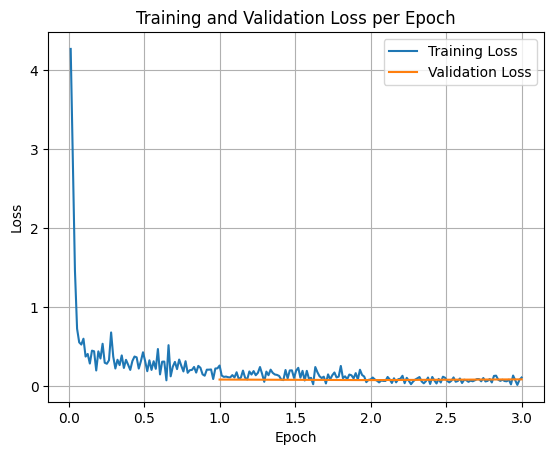

In [27]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Save the best model

We can save our best model to file using [`trl.SFTTrainer.save_model`](transformers.Trainer.save_model).


In [28]:
# Save the model
trainer.save_model()

### Optional: Remove checkpoints

When we upload our model to Hugging Face, a typical practice is to upload a certain folder (e.g. `checkpoint_models/`) including all the contents so we get the artifacts such as `config.json`, `generation_config.json`, `tokenizer.json` and more.

However, if we've got a large number of checkpoints from a training run, this could lead to uploading too many files.

In [29]:
!ls ./checkpoint_models/

added_tokens.json    config.json	     special_tokens_map.json
chat_template.jinja  generation_config.json  tokenizer_config.json
checkpoint-142	     helper_functions.py     tokenizer.json
checkpoint-213	     model.safetensors	     tokenizer.model
checkpoint-71	     README.md		     training_args.bin


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Perhaps we don't want to upload the `checkpoint-XXX` files and only the remaining files such as `model.safetensors`.

Let's remove the `checkpoint_models/checkpoint-XXX/` files and their contents.

In [30]:
# Optional: Remove all the checkpoint folders (since we've already saved the best model)
!rm -rf ./checkpoint_models/checkpoint-*/*
!rm -rf ./checkpoint_models/checkpoint-*

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [31]:
!ls checkpoint_models/

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


added_tokens.json	helper_functions.py	 tokenizer_config.json
chat_template.jinja	model.safetensors	 tokenizer.json
config.json		README.md		 tokenizer.model
generation_config.json	special_tokens_map.json  training_args.bin


Much cleaner!

Let's load our fine-tuned model back in and inspect its performance on the test dataset and if it goes well, we'll upload it to the Hugging Face Hub.

## Load the trained model back in and see how it performs

We've now fine-tuned our own Gemma 3 270M to do a specific food and drink extraction task, let's load it back in and see how it performs.

In [32]:
# Load the fine-tuned model and see how it goes
from transformers import AutoTokenizer, AutoModelForCausalLM

CHECKPOINT_DIR_NAME = "./checkpoint_models"

print(f"[INFO] Loading in model from: {CHECKPOINT_DIR_NAME}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
)

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

# Check our loaded model (it's the same architecture as before except this time with updated weights)
loaded_model

[INFO] Loading in model from: ./checkpoint_models


The tokenizer you are loading from './checkpoint_models' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

Now let's create a `"text-generation"` pipeline by loading our `loaded_model` into a pipeline.

In [33]:
from transformers import pipeline

loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


### Performing inference with our fine-tuned model on the test dataset

Let's now perform inference with our fine-tuned model on a random sample from the test dataset, `dataset["test"]` (our model has never seen these samples).

If our model training went well, the outputs of our fine-tuned model should be aligned with the ground truth labels.

In [34]:
# Get a random sample
import random

random_test_idx = random.randint(0, len(dataset["test"])-1)
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=random_test_sample["prompt"],
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt, 
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output):\n{random_test_sample['gpt-oss-120b-label-condensed']}")

[INFO] Test sample input:
<bos><start_of_turn>user
The image shows a package of "Helpful Harvest" dried vegetables. The ingredients include a variety of vegetables such as zucchini, carrots, mushrooms, onions, capsicum, and celery. The product is made from 100% vegetables and includes wonky and overly abundant produce where possible. The package notes that the ingredients and percentages may differ due to seasonal availability.

The allergens listed are milk, eggs, soy, sesame seeds, hazelnuts, pistachios, cashews, and almonds. The nutrition information indicates that the package contains 4 servings, with each serving size being 10g. The average quantities per serving are as follows:
- Energy: 125 kJ
- Protein: 1.9 g
- Gluten: 0 g (marked as gluten-free)
- Fat, total: 0.3 g
- Saturated fat: 0 g
- Carbohydrate: 3.4 g
- Sugars: 3.4 g
- Fibre: 3.4 g
- Sodium: 2.1 g

The average quantities per 100g are:
- Energy: 1250 kJ
- Protein: 18.7 g
- Fat, total: 2.8 g
- Saturated fat: 0 g
- Carbohyd

Nice!! Looks like our fine-tuned model is doing quite well to reproduce the target labels.

We could keep going here and inspect the predictions against the ground truth (in fact, I'd encourage you to sample at least 25 different test items and inspect them), however, let's now upload our model to the Hugging Face Hub so it's reusable.

### Attempt 2: Testing our model on unformatted text

Machine learning models often want to predict on data in the same format they've been trained on.

For example, our model is capable of making predictions on raw text, however, it was trained to do food and drink extraction specifically on formatted text.

In [35]:
# Test the loaded model on raw text (this won't work as well as formatted text)
test_input_message_without_formatting = "Hello my name is Daniel!"
loaded_model_pipeline(test_input_message_without_formatting)

[{'generated_text': 'Hello my name is Daniel! \nfood_or_drink: 0\ntags: \nfoods: \ndrinks:'}]

Notice the model generates the same input?

What happens if we format the input?

Let's create a helper function to format our input text into message format.

In [36]:
def format_message(input):
    return [{"role": "user", "content": input}]

test_input_message_with_formatting = format_message(input=test_input_message_without_formatting)
test_input_message_with_formatting

[{'role': 'user', 'content': 'Hello my name is Daniel!'}]

Now we can turn it into a prompt with our `tokenizer` and the `apply_chat_template` method.

In [37]:
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=test_input_message_with_formatting,
                                                                   tokenize=False,
                                                                   add_generation_prompt=True)

input_prompt

'<bos><start_of_turn>user\nHello my name is Daniel!<end_of_turn>\n<start_of_turn>model\n'

Now our test input has been formatted in a style that our model has been trained on, let's test it and see how it goes.

In [38]:
loaded_model_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                             max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{loaded_model_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Hello my name is Daniel!<end_of_turn>
<start_of_turn>model


[INFO] Output:
food_or_drink: 0
tags: 
foods: 
drinks:


Excellent! Our model outputs in the exact format we were looking for! It no longer regenerates the input as it did before.

::: {.callout-tip}

The takeaway here is: if your model has been trained/fine-tuned on data in a certain format, when doing inference, always pass in data to the model in the same format its been trained on.

Otherwise, you'll likely get strange or incorrect outputs.

:::

Okay let's make another helper function to predict on any given sample input.

We'll also return the inference time of our model so we can see how long things take (a working model is one thing but if it takes too long, well then it might not be as useful as we'd like).

In [39]:
import time

def pred_on_text(input_text):
    start_time = time.time()
    
    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

example_input_text = "British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"
output_text, output_raw, output_total_time = pred_on_text(input_text=example_input_text)

print(f"[INFO] Input text:\n{example_input_text}\n")
print(f"[INFO] Model generated output text:\n{output_text}\n")
print(f"[INFO] Model full raw output:\n{output_raw}\n")
print(f"[INFO] Inference time:\n{output_total_time}\n")

[INFO] Input text:
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes

[INFO] Model generated output text:
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea

[INFO] Model full raw output:
[{'generated_text': [{'role': 'user', 'content': 'British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes'}, {'role': 'assistant', 'content': 'food_or_drink: 1\ntags: fi, di\nfoods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes\ndrinks: tea'}]}]

[INFO] Inference time:
0.6492



Outstanding!

Looks like our model is working well enough (of course we could always improve it over time with more testing and different samples).

Let's upload it to the Hugging Face Hub.

## Uploading our fine-tuned model to the Hugging Face Hub

Uploading our fine-tuned model to the Hugging Face Hub means we can easily load it in to another environment later on or share it with others so they can test it out.

To do so, we'll use the [`huggingface_hub`](https://huggingface.co/docs/huggingface_hub/en/index) library.

We'll use the [`huggingface_hub.create_repo`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.create_repo) to create a repository to store our model.

And then we can upload files/folders to our model repository using [`huggingface_hub.HfApi.upload_file`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_file) and [`huggingface_hub.HfApi.upload_folder`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_folder).

::: {.callout-note}
To use the `huggingface_hub` library, be sure to login and setup Hugging Face with a token locally or via Google Colab Secrets.

For example:

```
from huggingface_hub import login

# Run this and follow the steps
login()
```

See the [Setup guide](https://www.learnhuggingface.com/extras/setup) as well as [Hugging Face Hub documentation](https://huggingface.co/docs/hub/en/security-tokens) for more.
:::

Let's start by creating a repo, I'm going to call mine `mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1`.

My username for Hugging Face is `mrdbourke` so be sure to change it to your own.

In [40]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# Change this to your own 
HF_USERNAME = "mrdbourke" 

# Create the repo (this is in the format [Hugging Face Username]/[Target Model Name])
repo_id = f"{HF_USERNAME}/FoodExtract-gemma-3-270m-fine-tune-v1"

# Create the repo
create_repo(repo_id, 
            repo_type="model", 
            private=False, # optionally make the repo private if you'd like to upload sensitive information
            exist_ok=True)

RepoUrl('https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1')

### Create a README.md for our model

Now we'll create a `README.md` file for our model so people know how it was trained and how to use it.

Adding a README to a model is often referred to as a model card.

We can add some front matter to our [model card](https://huggingface.co/docs/hub/model-cards).

Front matter is similar to tags or metadata, it gets added in YAML format, for example:

```
---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---
```

In [ ]:
model_readme = r"""---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---

# FoodExtract-v1

This is a food and drink extraction language model built on [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Given raw text, it's designed to:

1. Classify the text into food or drink (e.g. "a photo of a dog" = not food or drink, "a photo of a pizza" = food or drink).
2. Tag the text with one or more tags (see tags_dict below).
3. Extract the edible food-related items as a list.
4. Extract the edible drink-related items as a list.

For example, the input text might be:

```
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes
```

And the model will generate:

```
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea
```

This model can be used for filtering a large image caption (e.g. [DataComp-1B](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B)) text dataset for food and drink related items.

## Dataset

The model was trained on the [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.

This dataset contains 1400 samples of raw text and JSON output pairs of structured food extractions provided by `gpt-oss-120b`.

For example, a raw image caption input might be:

```
another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky
```

And the `gpt-oss-120b` generated output (JSON) would be:

```
{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}
```

This is condensed to:

```
food_or_drink: 0\ntags: \nfoods: \ndrinks:
```

### Tags dictionary mapping

These tags are designed for fast filtering.

For example, the model can assign a certain tag based on what's in the raw text and then we can filter for "ingredient list" items.

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

## Helper functions

The model is trained to output a condensed version of the structured data.

We do this so the model can generate less tokens (e.g. it doesn't have to generate JSON outputs).

The following functions help to condense and uncondense raw text outputs/inputs into the desired structure.

```python
def condense_output(original_output):
    '''Helper function to condense a given FoodExtract string.
    
    Example input: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}

    Example output: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:'''

    condensed_output_string_base = '''food_or_drink: <is_food_or_drink>
    tags: <output_tags>
    foods: <food_items>
    drinks: <drink_items>'''

    is_food_or_drink = str(1) if str(original_output["is_food_or_drink"]).lower() == "true" else str(0)
    tags = ", ".join(original_output["tags"]) if len(original_output["tags"]) > 0 else ""
    foods = ", ".join(original_output["food_items"]) if len(original_output["food_items"]) > 0 else ""
    drinks = ", ".join(original_output["drink_items"]) if len(original_output["drink_items"]) > 0 else ""

    condensed_output_string_formatted = condensed_output_string_base.replace("<is_food_or_drink>", is_food_or_drink).replace("<output_tags>", tags).replace("<food_items>", foods).replace("<drink_items>", drinks)

    return condensed_output_string_formatted.strip()

def uncondense_output(condensed_output):
    '''Helper to go from condensed output to uncondensed output.

    Example input: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:

    Example output: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}
    '''

    condensed_list = condensed_output.split("\n")

    condensed_dict_base = {
        "is_food_or_drink": "",
        "tags": [],
        "food_items": [],
        "drink_items": []
    }

    # Set values to defaults
    food_or_drink_item = None
    tags_item = None
    foods_item = None
    drinks_item = None

    # Extract items from condensed_list
    for item in condensed_list:
        if "food_or_drink:" in item.strip():
            food_or_drink_item = item

        if "tags:" in item:
            tags_item = item

        if "foods:" in item:
            foods_item = item

        if "drinks:" in item:
            drinks_item = item

    if food_or_drink_item:
        is_food_or_drink_bool = True if food_or_drink_item.replace("food_or_drink: ", "").strip() == "1" else False
    else:
        is_food_or_drink_bool = None

    if tags_item:
        tags_list = [item.replace("tags: ", "").replace("tags:", "").strip() for item in tags_item.split(", ")]
        tags_list = [item for item in tags_list if item] # Filter for empty items
    else:
        tags_list = []

    if foods_item:
        foods_list = [item.replace("foods:", "").replace("foods: ", "").strip() for item in foods_item.split(", ")]
        foods_list = [item for item in foods_list if item] # Filter for empty items
    else:
        foods_list = []

    if drinks_item:
        drinks_list = [item.replace("drinks:", "").replace("drinks: ", "").strip() for item in drinks_item.split(", ")]
        drinks_list = [item for item in drinks_list if item] # Filter for empty items
    else:
        drinks_list = []

    condensed_dict_base["is_food_or_drink"] = is_food_or_drink_bool
    condensed_dict_base["tags"] = tags_list
    condensed_dict_base["food_items"] = foods_list
    condensed_dict_base["drink_items"] = drinks_list

    return condensed_dict_base
````

## Quick start

```python
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create a sample to predict on
input_text = "A plate with bacon, eggs and toast on it"
input_text_user = [{'content': input_text, 'role': 'user'}]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=input_text_user,
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt, 
                                        max_new_tokens=256)

# View the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
```

You should see an output similar to:

```
[INFO] Test sample input:
<bos><start_of_turn>user
A plate with bacon, eggs and toast on it<end_of_turn>
<start_of_turn>model

[INFO] Fine-tuned model output:
food_or_drink: 1
tags: fi
foods: bacon, eggs, toast
drinks:
```

## Training procedure

This model was trained with SFT (Supervised Fine-Tuning) via Hugging Face's TRL library.

See the full training walkthrough at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial

## Citations

* Reference for structured data extraction was taken from the paper [*Essential-Web v1.0: 24T tokens of organized web data*](https://huggingface.co/papers/2506.14111) and the subsequent fine-tuned model [`EssentialAI/eai-distill-0.5b`](https://huggingface.co/EssentialAI/eai-distill-0.5b)."""

# Save README to file
with open(f"{CHECKPOINT_DIR_NAME}/README.md", "w") as f:
    f.write(model_readme)

### Upload the contents of our checkpoint model folder to the Hugging Face Hub

Now we've created a model repository (repo for short) and model card, let's upload our `checkpoint_models/` folder contents to the Hugging Face Hub.

To do so, we'll use the [`upload_folder`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_folder) method. 

This may take a few minutes depending on your internet connection.

In [42]:
# Upload the entire model folder containing our model files and README.md
print(f"[INFO] Uploading checkpoint directory: {CHECKPOINT_DIR_NAME} to Hugging Face repo: {repo_id}")
api.upload_folder(
    folder_path="./checkpoint_models/",
    repo_id=repo_id,
    repo_type="model"
)

[INFO] Uploading checkpoint directory: ./checkpoint_models to Hugging Face repo: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1/commit/dbd2032d7e6cbdb641dc8263142b91a4ebceee00', commit_message='Upload folder using huggingface_hub', commit_description='', oid='dbd2032d7e6cbdb641dc8263142b91a4ebceee00', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1'), pr_revision=None, pr_num=None)

Woohoo! Our model is officially on the Hugging Face Hub.

You can download it and view the model card here: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1/ (note: change to your own username if you'd like to see your own model).

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/03-learn-hf-fine-tune-llm-model-card-with-details.png"
     alt="
An educational screenshot titled 'Model Card' displays a Hugging Face repository page for a food extraction model. Three labeled arrows point to specific sections: a green arrow identifies the 'Model ID' at the top, a pink arrow highlights 'Metadata on model parameters' showing technical specs like tensor type and model size, and a blue arrow points to a descriptive section containing 'Details on how the model was trained and what it can do'. The model, named 'FoodExtract-gemma-3-270m-fine-tune-v1', is described as being built on 'Gemma 3 270M' to classify text, tag content, and extract food or drink items. A footer link provides the source URL for the model page." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>A Model Card is similar to a README.md file. It's a place to communicate details about your model including what it does, how it was trained and how to use it. On Hugging Face, the model page also shows the Model ID you can copy and use in various workflows. Adding details to your model card is a helpful way to communicate to others (and your future self) the most important information about your model.</figcaption>
</figure>

Now not only can we redownload it and use it again, others can download it and use it for themselves (of course you can make the model private if you like too).

## Turning our model into a demo

Right now our model seems to be working quite well for our specific use case.

However, it takes some coding to be able to use it.

What if we wanted to allow someone who wasn't familiar with programming to try it out?

To do so, we can turn our model into a [Gradio](https://www.gradio.app) demo and upload it to [Hugging Face Spaces](https://huggingface.co/spaces) (a place to share all kinds of small applications).

Gradio allows us to turn our model into an easy to use and sharable demo anyone can try.

Gradio demos work on the premise of: 

```
input (text) -> function (our model) -> output (text) 
```

We've already go a function ready with `pred_on_text` so we can wrap this with some Gradio code.

To create a sharable demo, we'll need the following files:

* `app.py` - Entry point for our app, all of our application code will go in here.
* `README.md` - Tells people what our app does.
    * **Note:** Hugging Face Spaces use a special "front matter" (text at the start of a `README.md` file) to add various attributes to a Hugging Face Space, we'll see this below.
* `requirements.txt` - Tells Hugging Face Spaces what our app requires.
    * `torch`, `transformers`, `gradio`, `accelerate`
 
Let's make a folder to store our demo application.


In [43]:
!mkdir demos/
!mkdir demos/FoodExtract

mkdir: cannot create directory ‘demos/’: File exists


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


mkdir: cannot create directory ‘demos/FoodExtract’: File exists


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Creating the `app.py` file

When running our app on Hugging Face Spaces, we have the option to run our model on a GPU thanks to Hugging Face's [ZeroGPU](https://huggingface.co/docs/hub/en/spaces-zerogpu) feature. 

This is optional, however, it's highly recommend you run a model such as Gemma 3 270M on a GPU as we'll see significant speedups as compared to running on CPU.

You can run a function on a GPU by importing `spaces` and then using the `@spaces.GPU` decorator on your target function.

For example:

```python
import spaces

@spaces.GPU
def function_to_run_on_the_gpu():
    pass
```

To ensure your model runs on the GPU, be sure to select a [ZeroGPU instance](https://huggingface.co/docs/hub/en/spaces-zerogpu) in your Hugging Face Space settings.

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/04-learn-hf-fine-tune-llm-zeroGPU.png"
     alt="An educational screenshot titled 'ZeroGPU' showcases the hardware selection interface on Hugging Face Spaces for a project named 'FoodExtract-v1'. A green arrow points to the 'ZeroGPU' option, accompanied by a handwritten note stating that it 'offers a way to get free access to a GPU on your demo Space'. The interface displays various hardware tiers, including 'CPU basic', 'CPU upgrade', and several paid Nvidia GPU configurations, with the ZeroGPU box highlighted by a dotted green border. A footer includes a 'Source' URL directing to the specific settings page on Hugging Face." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>Most modern models will often see speedup benefits from using a GPU. A very nice feature of Hugging Face Spaces is the ability to select the ZeroGPU option in the settings. This allocates a GPU to your Hugging Face Space from a shared pool of GPU resources. If you are a PRO user, you get even more access. See the ZeroGPU documentation for more information.</figcaption>
</figure>

In [ ]:
%%writefile demos/FoodExtract/app.py

# Load dependencies
import time
import transformers
import torch
import spaces # Optional: run our model on the GPU (this will be much faster inference)

import gradio as gr

from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import pipeline

@spaces.GPU # Optional: run our model on the GPU (this will be much faster inference)
def pred_on_text(input_text):
    start_time = time.time()
    
    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

# Load the model (from our Hugging Face Repo)
# Note: You may have to replace my username `mrdbourke` for your own
MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create the demo
description = """Extract food and drink items from text with a fine-tuned SLM (Small Language Model) or more specifically a fine-tuned [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Our model has been fine-tuned on the [FoodExtract-1k dataset](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k). 

* Input (str): Raw text strings or image captions (e.g. "A photo of a dog sitting on a beach" or "A breakfast plate with bacon, eggs and toast")
* Output (str): Generated text with food/not_food classification as well as noun extracted food and drink items and various food tags.

For example:

* Input: "For breakfast I had eggs, bacon and toast and a glass of orange juice"
* Output: 

```
food_or_drink: 1
tags: fi, di
foods: eggs, bacon, toast
drinks: orange juice
```

See full fine-tuning code at [learnhuggingface.com](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial).
"""

# Create the Gradio text in and out interface
demo = gr.Interface(fn=pred_on_text,
                    inputs=gr.TextArea(lines=4, label="Input Text"),
                    outputs=[gr.TextArea(lines=4, label="Generated Text"),
                             gr.TextArea(lines=7, label="Raw Output"),
                             gr.Number(label="Generation Time (s)")],
                    title="🍳 Structured FoodExtract with a Fine-Tuned Gemma 3 270M",
                    description=description,
                    examples=[["Hello world! This is my first fine-tuned LLM!"],
                              ["A plate of food with grilled barramundi, salad with avocado, olives, tomatoes and Italian dressing"],
                              ["British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"],
                              ["Steak tacos"],
                              ["A photo of a dog sitting on a beach"]]
)

if __name__ == "__main__":
    demo.launch(share=False)


Writing demos/FoodExtract/app.py


### Create the `README.md` file

The `README.md` file will tell people what our app does.

We could add more information here if we wanted to but for now we'll keep it simple.

Notice the special text at the top of the file below (the text between the `---`), these are some settings for the Space, you can see the [settings for these in the docs](https://huggingface.co/docs/hub/en/spaces-config-reference).

In [44]:
%%writefile demos/FoodExtract/README.md
---
title: FoodExtract Fine-tuned LLM Structued Data Extractor v1
emoji: 📝➡️🍟
colorFrom: green
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

"""
Fine-tuned Gemma 3 270M to extract food and drink items from raw text.

Input can be any form of real text (mostly focused on shorter image caption-like texts):

```
A truly eclectic and mouth-watering feast is laid out on the table, featuring savory favorites like crispy fried chicken, 
a perfectly seared steak, and loaded tacos, complete with a side of creamy mayonnaise. To balance the heavier mains, 
a vibrant assortment of fresh fruit sits nearby, including a crisp red apple, a tropical pineapple, and a scattering of 
sweet cherries. Thirst-quenching options complete this extravagant spread, with a classic iced latte, an earthy matcha latte, 
and a simple, refreshing glass of milk ready to be enjoyed.
```

And output will be a formatted string such as the following:

```
food_or_drink: 1
tags: fi, re
foods: tacos,red apple, pineapple, cherries, fried chicken, steak, mayonnaise
drinks: iced latte, matcha latte, milk
```

The tags map to the following items:

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

* You can see walkthrough step by step code details at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial 
* See the fine-tuning dataset: https://huggingface.co/datasets/mrdbourke/FoodExtract-1k
* See the fine-tuned model: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1
"""

Overwriting demos/FoodExtract/README.md


### Creating a `requirements.txt` file

This will tell the Hugging Face Space what libraries we'd like it to run inside.

In [45]:
%%writefile demos/FoodExtract/requirements.txt
transformers
gradio
torch
accelerate

Overwriting demos/FoodExtract/requirements.txt


### Uploading our demo to the Hugging Face Hub

We can upload our demo to the Hugging Face Hub in a similar way to uploading our model.

We could also upload it file by file via the Hugging Face Spaces interface.

But let's stick to the code-first approach.

To do so, we'll:

1. Import the required `huggingface_hub` methods for uploading to the Hugging Face Hub.
2. Define the parameters we'd like to use for the upload.
3. Create a `"space"` repository on the Hugging Face Hub using `create_repo`.
4. Get the full repository name using `get_full_repo_name`, we can use this for uploading a target folder.
5. Upload our target demo folder with our `app.py`, `requirements.txt` and `README.md` file to our target repository.

In [46]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading multiple files (in a folder)
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demos/FoodExtract/"
HF_TARGET_SPACE_NAME = "FoodExtract-v1"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub 
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists 
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading FoodExtract demo app.py"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on Hugging Face Hub with name: FoodExtract-v1
[INFO] Full Hugging Face Hub repo name: mrdbourke/FoodExtract-v1
[INFO] Uploading demos/FoodExtract/ to repo: mrdbourke/FoodExtract-v1
[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/mrdbourke/FoodExtract-v1/tree/main/.


Nice!

It looks like our demo upload worked!

### Trying our demo right from within our notebook

We can try it out via the URL (in my case, it's: [https://huggingface.co/spaces/mrdbourke/FoodExtract-v1](https://huggingface.co/spaces/mrdbourke/FoodExtract-v1)). 

And we can even embed it right in our notebook by going to the three dots on the Hugging Face Space and then clicking "Embed this Space".

In [48]:
from IPython.display import HTML

html_code = """<iframe
	src="https://mrdbourke-foodextract-v1.hf.space"
	frameborder="0"
	width="850"
	height="1000"
></iframe>"""

display(HTML(html_code))

How cool!

We've now got a sharable demo of a fine-tuned LLM which anyone can try out for themselves.

## Summary

Congratulations!

You've now officially fine-tuned your own SLM for structured data extraction!

We've come a long way from the base Gemma 3 270M model, fine-tuning it on our custom dataset and then evaluating it for our specific task.

We've now got a fine-tuned model artifact we could share with others and re-use over and over again.

We've also got a Hugging Face Space with a demo application running that we could share with others to easily try out our model.

The data -> model -> demo workflow is complete!

One of the biggest takeaways is that language models (large and small) operate on the premise of **tokens in and tokens out**.

This means, if you can get the right input tokens (image captions in our case) and desired output tokens (structured extracted food data) lined up, you can likely find a way to train a model to repeat the process.

### Extensions

Our model works quite well for our given task. 

However, if we wanted to improve the overall workflow, there are several avenues we could explore next.

1. **Improve/increase the data sampling** - If our model makes mistakes, one of the strongest levers we have to fix this is to improve the input data. For example, more samples on certain tasks where the model is weaker. I've gone ahead and done this by creating [`mrdbourke/FoodExtract-135k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-135k), a dataset which is ~80x larger than the one we used in this notebook. The resulting fine-tuned model ([`mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v2`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v2)) uses the same base model (Gemma 3 270M), however it has now seen far more samples. You can see the demo at [`mrdbourke/FoodExtract-v2`](https://huggingface.co/spaces/mrdbourke/FoodExtract-v2).
2. **Quantization** - Right now our model is ~500MB in `torch.bfloat16` precision. Are there quantization options which we could use to make the model smaller and more memory efficient? I'd try searching for "gemma 3 270m quantization techniques".
3. **Output compression/decompression** - Currently, our model is trained to produce a compressed YAML-like format. But is there a better compression option to generate even less tokens (and speeding up inference)? Or perhaps we could decompress the outputs such as the tags (e.g. `re` -> `recipe`) so the model generates full tags and perhaps gets a more accurate representation? If you're going to be training models to generate a specific output, it's worth considering how the output could be best tailored to your setting.
4. **Test the model on a large unseen sample dataset** - We've tested our model on the test dataset (samples our model never saw during training), perhaps we'd like to test our model on a larger corpus? You could find a large dataset (such as [DataComp-1B](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B)) and try our model across a large sample, say 10,000+ captions and see how it performs on those. If there are any noticable failure cases, you could try and add those samples back into the training data and improve the model in the next run. For an example of the the FoodExtract model running in the wild, see the [`mrdbourke/Recap-DataComp-1B-FoodOrDrink`](https://huggingface.co/datasets/mrdbourke/Recap-DataComp-1B-FoodOrDrink) dataset I'm working on for filtering a large 1 billion+ sample dataset specifically for food/drink images and items.
5. **Try an inference engine for performance increase** - Right now we're using Hugging Face's `transformers` library to run our model which is based on PyTorch. However, there are dedicated inference engines such as [vLLM](https://docs.vllm.ai/en/latest/getting_started/quickstart/) which are engineered to improve the throughput of our model. In my experience, I've often found a 5-10x or more improvement on throughput speed (e.g. 200 samples/second with vLLM rather than 20 samples/second with pure `transformers`) when using a dedicated inference engine. For more, I'd try searching "vllm gemma 3 example".

### Extra-curriculum

If you want to learn more or continue the current project, I'd recommend trying the following.

* TK - add notebook links for the following techniques, get the code working but add notes for the text around it to be improving
* **Batched inference with Hugging Face Transformers** - Let's say you wanted to perform inference with the model across ~1 billion samples. Doing this 1 by 1 would take quite a long time. To fix this, you can perform batched inference, meaning the model predicts on multiple samples at a time (e.g. 16 samples at once instead of 1). This often dramatically speeds up inference time per sample and is highly recommended in practice.
* **Structured data extraction evaluation** - In this notebook we evaluated our model's output after fine-tuning by manually inspecting samples. And so far this *looks* good. However, in practice or a production setting, you'll likely want to evaluate your models outputs in a more structured way. This notebook focuses on doing just that. Validating our model's output structure as well as applying metrics to actual extraction values compared to the ground truth. Having these specific insights we can plan out how to improve our model's performance in the future.
* **vLLM batched inference** - If you want to step things up even further with faster inference, you'll likely want to use a dedicated inference engine such as vLLM. Because vLLM is designed for fast inference, you'll often see significant speed increases compared to using native Hugging Face `transformers`. See the reference notebook for an example (TK - link).
* **Advance your model with Reinforcement Learning (RL)** - In this notebook we've used Supervised Fine-tuning (SFT) to get to produce certain outputs given certain inputs. However, for more advanced input and output pairs, you might want to look into reinforcement learning (RL). RL is a technique which uses reward functions to train a model to reproduce certain behaviours. For example, if you were using RL to improve a model's ability to solve a math problem, it might get a +1 for getting the right answer. This is a simplified overview but RL is a potential next step in the training journey of our model. For more resources on this, look into:
    * [Reinforcement Learning from Human Feedback (RLHF)](https://en.wikipedia.org/wiki/Reinforcement_learning_from_human_feedback) - If you want your model to sound a particular way, this is a popular technique to train a model to learn to replicate human preferences.
    * [GRPO Trainer in Hugging Face TRL](https://huggingface.co/docs/trl/grpo_trainer) - GRPO (Group Relative Policy Optimization) is a popular reinforcement learning algorithm for training models. It (and many other RL algorithms) are available in the TRL library.
    * [No GPU left behind: Unlocking Efficiency with Co-located vLLM in TRL](https://huggingface.co/blog/vllm-colocate) - Example of using vLLM to generate samples which help a model improve its own training over time. Workflow: generate responses with vLLM during training -> integrate responses back into training -> receive feedback -> keep improving training.

### Extra resources

* For more on LLM evaluations, I'd highly recommend checking out Hamel Husain's blog on [*LLM Evals: Everything You Need to Know*](https://hamel.dev/blog/posts/evals-faq/), also, the rest of Hamel's blog is full of incredible resources so dig around.
* For more on LLM training in general, the [*Post Training 101*](https://tokens-for-thoughts.notion.site/post-training-101 ) blog post by [Han Fang](https://hanfang.info/) and [Karthik Abinav Sankararaman](https://karthikabinavs.xyz/) is an excellent read and guide to various different training techniques to improve a base LLM model. 
* For a nice experiment on whether you should use SFT (Supervised Fine-tuning, what we've used in this notebook) or RL (Reinforcement Learning) for smaller models, see [*When Does Reinforcement Learning Help Small Language Models?*](https://www.distillabs.ai/blog/when-does-reinforcement-learning-help-small-language-models) by Distil Labs.